In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultiLabelImageFolder(Dataset):
    """Кастомный Dataset для multi-label классификации"""
    def __init__(self, data_path, transform=None, label_file=None):
        self.data_path = data_path
        self.transform = transform
        
        self.image_paths = []
        self.labels = []
        self.classes = []
        
        if label_file and os.path.exists(label_file):
            self._load_from_csv(label_file)
        else:
            self._load_from_folders()
    
    def _load_from_folders(self):
        """Загрузка данных из структуры папок (multi-label)"""
        self.classes = sorted([d for d in os.listdir(self.data_path) 
                             if os.path.isdir(os.path.join(self.data_path, d))])
        
        class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        image_dict = {}
        
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_path, class_name)
            if not os.path.isdir(class_path):
                continue
                
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    
                    if img_path not in image_dict:
                        image_dict[img_path] = []
                    
                    image_dict[img_path].append(class_idx)
        
        self.image_paths = list(image_dict.keys())
        self.labels = [self._to_multi_hot(labels, len(self.classes)) 
                      for labels in image_dict.values()]
        
        print(f"Найдено {len(self.image_paths)} изображений с {len(self.classes)} классами")
    
    def _load_from_csv(self, label_file):
        """Загрузка данных из CSV файла с multi-label метками"""
        df = pd.read_csv(label_file)
        self.classes = [col for col in df.columns if col not in ['image', 'filename']]
        
        for _, row in df.iterrows():
            img_name = row['image'] if 'image' in row else row['filename']
            img_path = os.path.join(self.data_path, img_name)
            
            if os.path.exists(img_path):
                self.image_paths.append(img_path)
                labels = [int(row[cls]) for cls in self.classes]
                self.labels.append(labels)
    
    def _to_multi_hot(self, indices, num_classes):
        """Конвертирует список индексов в multi-hot вектор"""
        multi_hot = [0] * num_classes
        for idx in indices:
            if idx < num_classes:
                multi_hot[idx] = 1
        return multi_hot
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.float32)
        return image, label

def load_and_split_data(data_path, train_ratio=0.8, label_file=None):
    """Загружает данные для multi-label классификации и разделяет на выборки"""
    print(f"Загрузка multi-label данных из: {data_path}")
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Папка {data_path} не существует!")
        return None, None, None
    
    full_dataset = MultiLabelImageFolder(
        data_path=data_path,
        transform=train_transform,
        label_file=label_file
    )
    
    print(f"Найдено классов: {full_dataset.classes}")
    print(f"Всего изображений: {len(full_dataset)}")
    
    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    print(f"Тренировочные данные: {train_size} изображений")
    print(f"Тестовые данные: {test_size} изображений")
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    test_dataset_full = MultiLabelImageFolder(
        data_path=data_path,
        transform=val_transform,
        label_file=label_file
    )
    test_dataset = torch.utils.data.Subset(test_dataset_full, test_dataset.indices)
    
    return train_dataset, test_dataset, full_dataset.classes

class MultiLabelLoss(nn.Module):
    """Loss функция для multi-label классификации"""
    def __init__(self):
        super(MultiLabelLoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
    
    def forward(self, outputs, targets):
        return self.bce_loss(outputs, targets)

def calculate_multi_label_accuracy(outputs, targets, threshold=0.5):
    """Вычисляет accuracy для multi-label классификации"""
    with torch.no_grad():
        preds = torch.sigmoid(outputs) > threshold
        correct = (preds == targets.bool()).float()
        
        exact_match = (correct.sum(dim=1) == targets.size(1)).float().mean()
        label_accuracy = correct.mean()
        
        return exact_match.item(), label_accuracy.item()

class ResNetWithBBox(nn.Module):
    """
    ResNet модель с добавлением параметров bounding box к эмбеддингам
    перед классификационной частью
    """
    def __init__(self, num_classes, pretrained=True, bbox_dim=4):
        super(ResNetWithBBox, self).__init__()
        
        self.resnet = models.resnet18(pretrained=pretrained)
        
        self.original_fc_in_features = self.resnet.fc.in_features
        
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])
        
        self.bbox_dim = bbox_dim
        self.classifier = nn.Linear(
            self.original_fc_in_features + bbox_dim, 
            num_classes
        )
        
        nn.init.normal_(self.classifier.weight, 0, 0.01)
        nn.init.constant_(self.classifier.bias, 0)
        
        print(f"Модель инициализирована:")
        print(f"  - Входные признаки ResNet: {self.original_fc_in_features}")
        print(f"  - BBox параметры: {bbox_dim}")
        print(f"  - Выходные классы: {num_classes}")
    
    def forward(self, x, bbox_params=None):
        """
        Forward pass с дополнительными bbox параметрами
        
        Args:
            x: входные изображения [batch_size, 3, H, W]
            bbox_params: тензор bbox параметров [batch_size, 4]
                       формат: [x_center, y_center, width, height] (нормированные 0-1)
        """
        features = self.resnet(x)
        features = features.view(features.size(0), -1)
        
        if bbox_params is None:
            batch_size = features.size(0)
            bbox_params = torch.zeros(batch_size, self.bbox_dim).to(features.device)
        
        combined_features = torch.cat([features, bbox_params], dim=1)
        
        output = self.classifier(combined_features)
        
        return output

def create_resnet_with_bbox(num_classes, pretrained=True):
    """Создает модель ResNet с поддержкой bbox параметров"""
    return ResNetWithBBox(num_classes, pretrained)

def prepare_bbox_params(bbox_tensor, img_size=(224, 224)):
    """
    Подготавливает bbox параметры для модели
    
    Args:
        bbox_tensor: тензор с bbox в формате [x1, y1, w, h] или [x_center, y_center, w, h]
        img_size: размер изображения (H, W) для нормализации
        
    Returns:
        Нормированные bbox параметры [x_center, y_center, width, height] в диапазоне [0, 1]
    """
    if bbox_tensor.dim() == 1:
        bbox_tensor = bbox_tensor.unsqueeze(0)
    
    img_h, img_w = img_size
    bbox_normalized = bbox_tensor.clone().float()
    
    if bbox_normalized.size(1) == 4:
        x1, y1, w, h = bbox_normalized[:, 0], bbox_normalized[:, 1], bbox_normalized[:, 2], bbox_normalized[:, 3]
        x_center = (x1 + w/2) / img_w
        y_center = (y1 + h/2) / img_h
        width_norm = w / img_w
        height_norm = h / img_h
    else:
        x_center, y_center, width_norm, height_norm = bbox_normalized[:, 0], bbox_normalized[:, 1], bbox_normalized[:, 2], bbox_normalized[:, 3]
        x_center = x_center / img_w
        y_center = y_center / img_h
        width_norm = width_norm / img_w
        height_norm = height_norm / img_h
    
    bbox_params = torch.stack([x_center, y_center, width_norm, height_norm], dim=1)
    
    bbox_params = torch.clamp(bbox_params, 0.0, 1.0)
    
    return bbox_params

def yolo_to_bbox_params(yolo_detection, img_size=(224, 224)):
    """
    Конвертирует детекцию YOLO в bbox параметры для ResNet
    
    Args:
        yolo_detection: результат YOLO детекции
        img_size: размер изображения
        
    Returns:
        bbox_params: тензор [x_center, y_center, width, height] нормированный [0, 1]
    """
    if len(yolo_detection.boxes) == 0:
        return torch.tensor([0.5, 0.5, 0.1, 0.1]).float()
    
    box = yolo_detection.boxes[0]
    xywh = box.xywh[0].cpu().numpy()  # [x_center, y_center, width, height]
    
    bbox_tensor = torch.tensor(xywh).float()
    bbox_params = prepare_bbox_params(bbox_tensor, img_size)
    
    return bbox_params.squeeze(0)

def train_model_with_bbox(model, train_loader, val_loader, criterion, optimizer, epochs=25, bbox_provider=None):
    """
    Обучение модели с bbox параметрами
    
    Args:
        bbox_provider: функция, которая возвращает bbox параметры для batch
    """
    model = model.to(device)
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            if bbox_provider is not None:
                bbox_params = bbox_provider(images, labels)
                bbox_params = bbox_params.to(device)
                outputs = model(images, bbox_params)
            else:
                outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        model.eval()
        total_exact_accuracy = 0.0
        total_label_accuracy = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                if bbox_provider is not None:
                    bbox_params = bbox_provider(images, labels)
                    bbox_params = bbox_params.to(device)
                    outputs = model(images, bbox_params)
                else:
                    outputs = model(images)
                
                exact_acc, label_acc = calculate_multi_label_accuracy(outputs, labels)
                total_exact_accuracy += exact_acc
                total_label_accuracy += label_acc
                val_batches += 1
        
        epoch_loss = running_loss / len(train_loader)
        epoch_exact_accuracy = 100 * total_exact_accuracy / val_batches
        epoch_label_accuracy = 100 * total_label_accuracy / val_batches
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_label_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')
        print(f'Exact Match Accuracy: {epoch_exact_accuracy:.2f}%')
        print(f'Label Accuracy: {epoch_label_accuracy:.2f}%')
        print('-' * 50)
    
    return train_losses, val_accuracies

class YOLOBBoxProvider:
    """Провайдер bbox параметров используя YOLO модель"""
    def __init__(self, yolo_model_path, img_size=(224, 224)):
        self.yolo_model = YOLO(yolo_model_path)
        self.img_size = img_size
    
    def __call__(self, images, labels=None):
        """
        Для batch изображений возвращает bbox параметры
        """
        batch_size = images.size(0)
        bbox_params_list = []
        
        for i in range(batch_size):
            img_tensor = images[i]
            img_np = (img_tensor.cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
            img_pil = Image.fromarray(img_np)
            
            results = self.yolo_model(img_pil)
            
            if len(results) > 0 and len(results[0].boxes) > 0:
                bbox_params = yolo_to_bbox_params(results[0], self.img_size)
            else:
                bbox_params = torch.tensor([0.5, 0.5, 0.1, 0.1]).float()
            
            bbox_params_list.append(bbox_params)
        
        return torch.stack(bbox_params_list)

def check_data_structure():
    """Проверяет существование различных возможных путей"""
    possible_paths = [
        "../merged_augmented_data",
        "merged_augmented_data", 
        "./merged_augmented_data",
        r"C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Processed_data\merged_augmented_data"
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Найдена папка: {path}")
            print(f"Содержимое: {os.listdir(path)}")
            return path
        else:
            print(f"Папка не найдена: {path}")
    
    return None

if __name__ == "__main__":
    print("=" * 60)
    print("MULTI-LABEL КЛАССИФИКАЦИЯ С BBOX ПАРАМЕТРАМИ")
    print("=" * 60)
    
    data_path = check_data_structure()
    
    if data_path is None:
        print("\nНе удалось найти папку с данными!")
        exit()
    
    print(f"\nИспользуем путь: {data_path}")
    
    try:
        train_dataset, test_dataset, class_names = load_and_split_data(data_path, train_ratio=0.8)
        
        if train_dataset is None:
            exit()
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Classes: {class_names}")
        print(f"Number of classes: {len(class_names)}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        num_classes = len(class_names)
        model = create_resnet_with_bbox(num_classes, pretrained=True)
        
        criterion = MultiLabelLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        yolo_provider = None
        
        print(f"\nНАЧАЛО ОБУЧЕНИЯ MULTI-LABEL МОДЕЛИ С BBOX")
        print("=" * 60)
        
        train_losses, val_accuracies = train_model_with_bbox(
            model, train_loader, test_loader, criterion, optimizer, 
            epochs=5, bbox_provider=yolo_provider
        )
        
        if len(train_losses) > 0:
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 2, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.grid(True)
            
            plt.subplot(1, 2, 2)
            plt.plot(val_accuracies)
            plt.title('Validation Label Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (%)')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'model_architecture': 'resnet18_with_bbox',
                'multi_label': True
            }, 'resnet18_with_bbox_multilabel.pth')
            
            print("✅ Multi-label model with BBox saved!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

def predict_with_bbox(model, image_path, yolo_model_path, class_names, device, transform=None, threshold=0.5):
    """
    Предсказание с использованием YOLO для получения bbox
    """
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    yolo_model = YOLO(yolo_model_path)
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    yolo_results = yolo_model(image)
    bbox_params = yolo_to_bbox_params(yolo_results[0])
    bbox_params = bbox_params.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor, bbox_params)
        probabilities = torch.sigmoid(outputs)
        predicted_probs = probabilities.cpu().numpy()[0]
        
        predicted_labels = (predicted_probs > threshold).astype(int)
        predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
    
    result = {
        'image_path': image_path,
        'predicted_classes': predicted_classes,
        'predicted_probs': predicted_probs,
        'bbox_params': bbox_params.cpu().numpy()[0],
        'class_probabilities': {
            class_name: prob for class_name, prob in zip(class_names, predicted_probs)
        }
    }
    
    print(f"BBox параметры: x_center={bbox_params[0,0]:.3f}, y_center={bbox_params[0,1]:.3f}, "
          f"width={bbox_params[0,2]:.3f}, height={bbox_params[0,3]:.3f}")
    print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
    
    return result

def example_prediction():
    """Пример использования модели для предсказания"""
    try:
        checkpoint = torch.load('resnet18_with_bbox_multilabel.pth', map_location=device)
        class_names = checkpoint['class_names']
        
        model = create_resnet_with_bbox(len(class_names), pretrained=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        
        print("Модель загружена для предсказания")
        
        # result = predict_with_bbox(
        #     model=model,
        #     image_path="test_image.jpg",
        #     yolo_model_path="path/to/best.pt",
        #     class_names=class_names,
        #     device=device
        # )
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import traceback
import cv2
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class MultiLabelImageFolder(Dataset):
    """Кастомный Dataset для multi-label классификации"""
    def __init__(self, data_path, transform=None, label_file=None):
        self.data_path = data_path
        self.transform = transform
        
        self.image_paths = []
        self.labels = []
        self.classes = []
        
        if label_file and os.path.exists(label_file):
            self._load_from_csv(label_file)
        else:
            self._load_from_folders()
    
    def _load_from_folders(self):
        """Загрузка данных из структуры папок (multi-label)"""
        self.classes = sorted([d for d in os.listdir(self.data_path) 
                             if os.path.isdir(os.path.join(self.data_path, d))])
        
        class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        image_dict = {}
        
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(self.data_path, class_name)
            if not os.path.isdir(class_path):
                continue
                
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    
                    if img_path not in image_dict:
                        image_dict[img_path] = []
                    
                    image_dict[img_path].append(class_idx)
        
        self.image_paths = list(image_dict.keys())
        self.labels = [self._to_multi_hot(labels, len(self.classes)) 
                      for labels in image_dict.values()]
        
        print(f"Найдено {len(self.image_paths)} изображений с {len(self.classes)} классами")
    
    def _load_from_csv(self, label_file):
        """Загрузка данных из CSV файла с multi-label метками"""
        df = pd.read_csv(label_file)
        self.classes = [col for col in df.columns if col not in ['image', 'filename']]
        
        for _, row in df.iterrows():
            img_name = row['image'] if 'image' in row else row['filename']
            img_path = os.path.join(self.data_path, img_name)
            
            if os.path.exists(img_path):
                self.image_paths.append(img_path)
                labels = [int(row[cls]) for cls in self.classes]
                self.labels.append(labels)
    
    def _to_multi_hot(self, indices, num_classes):
        """Конвертирует список индексов в multi-hot вектор"""
        multi_hot = [0] * num_classes
        for idx in indices:
            if idx < num_classes:
                multi_hot[idx] = 1
        return multi_hot
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.float32)
        return image, label

def load_and_split_data(data_path, train_ratio=0.8, label_file=None):
    """Загружает данные для multi-label классификации и разделяет на выборки"""
    print(f"Загрузка multi-label данных из: {data_path}")
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Папка {data_path} не существует!")
        return None, None, None
    
    full_dataset = MultiLabelImageFolder(
        data_path=data_path,
        transform=train_transform,
        label_file=label_file
    )
    
    print(f"Найдено классов: {full_dataset.classes}")
    print(f"Всего изображений: {len(full_dataset)}")
    
    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    print(f"Тренировочные данные: {train_size} изображений")
    print(f"Тестовые данные: {test_size} изображений")
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    test_dataset_full = MultiLabelImageFolder(
        data_path=data_path,
        transform=val_transform,
        label_file=label_file
    )
    test_dataset = torch.utils.data.Subset(test_dataset_full, test_dataset.indices)
    
    return train_dataset, test_dataset, full_dataset.classes

class MultiLabelLoss(nn.Module):
    """Loss функция для multi-label классификации"""
    def __init__(self):
        super(MultiLabelLoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
    
    def forward(self, outputs, targets):
        return self.bce_loss(outputs, targets)

def calculate_multi_label_accuracy(outputs, targets, threshold=0.5):
    """Вычисляет accuracy для multi-label классификации"""
    with torch.no_grad():
        preds = torch.sigmoid(outputs) > threshold
        correct = (preds == targets.bool()).float()
        
        exact_match = (correct.sum(dim=1) == targets.size(1)).float().mean()
        label_accuracy = correct.mean()
        
        return exact_match.item(), label_accuracy.item()

class ResNetWithBBox(nn.Module):
    """
    ResNet модель с добавлением параметров bounding box к эмбеддингам
    перед классификационной частью
    """
    def __init__(self, num_classes, pretrained=True, bbox_dim=4):
        super(ResNetWithBBox, self).__init__()
        
        self.resnet = models.resnet18(pretrained=pretrained)
        
        self.original_fc_in_features = self.resnet.fc.in_features
        
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])
        
        self.bbox_dim = bbox_dim
        self.classifier = nn.Linear(
            self.original_fc_in_features + bbox_dim, 
            num_classes
        )
        
        nn.init.normal_(self.classifier.weight, 0, 0.01)
        nn.init.constant_(self.classifier.bias, 0)
        
        print(f"Модель инициализирована:")
        print(f"  - Входные признаки ResNet: {self.original_fc_in_features}")
        print(f"  - BBox параметры: {bbox_dim}")
        print(f"  - Выходные классы: {num_classes}")
    
    def forward(self, x, bbox_params=None):
        """
        Forward pass с дополнительными bbox параметрами
        
        Args:
            x: входные изображения [batch_size, 3, H, W]
            bbox_params: тензор bbox параметров [batch_size, 4]
                       формат: [x_center, y_center, width, height] (нормированные 0-1)
        """
        features = self.resnet(x)
        features = features.view(features.size(0), -1)
        
        if bbox_params is None:
            batch_size = features.size(0)
            bbox_params = torch.zeros(batch_size, self.bbox_dim).to(features.device)
        
        combined_features = torch.cat([features, bbox_params], dim=1)
        
        output = self.classifier(combined_features)
        
        return output

def create_resnet_with_bbox(num_classes, pretrained=True):
    """Создает модель ResNet с поддержкой bbox параметров"""
    return ResNetWithBBox(num_classes, pretrained)

def prepare_bbox_params(bbox_tensor, img_size=(224, 224)):
    """
    Подготавливает bbox параметры для модели
    """
    if bbox_tensor.dim() == 1:
        bbox_tensor = bbox_tensor.unsqueeze(0)
    
    img_h, img_w = img_size
    bbox_normalized = bbox_tensor.clone().float()
    
    if bbox_normalized.size(1) == 4:
        x1, y1, w, h = bbox_normalized[:, 0], bbox_normalized[:, 1], bbox_normalized[:, 2], bbox_normalized[:, 3]
        x_center = (x1 + w/2) / img_w
        y_center = (y1 + h/2) / img_h
        width_norm = w / img_w
        height_norm = h / img_h
    else:
        x_center, y_center, width_norm, height_norm = bbox_normalized[:, 0], bbox_normalized[:, 1], bbox_normalized[:, 2], bbox_normalized[:, 3]
        x_center = x_center / img_w
        y_center = y_center / img_h
        width_norm = width_norm / img_w
        height_norm = height_norm / img_h
    
    bbox_params = torch.stack([x_center, y_center, width_norm, height_norm], dim=1)
    bbox_params = torch.clamp(bbox_params, 0.0, 1.0)
    
    return bbox_params

class SimpleBBoxProvider:
    """Простейший провайдер bbox параметров"""
    def __init__(self, img_size=(224, 224)):
        self.img_size = img_size
    
    def __call__(self, images, labels=None):
        batch_size = images.size(0)
        bbox_params_list = []
        
        for i in range(batch_size):
            x_center = 0.5 + random.uniform(-0.2, 0.2)
            y_center = 0.5 + random.uniform(-0.2, 0.2)
            width = random.uniform(0.1, 0.4)
            height = random.uniform(0.1, 0.4)
            
            x_center = max(0.1, min(0.9, x_center))
            y_center = max(0.1, min(0.9, y_center))
            width = max(0.05, min(0.5, width))
            height = max(0.05, min(0.5, height))
            
            bbox_params = torch.tensor([x_center, y_center, width, height]).float()
            bbox_params_list.append(bbox_params)
        
        return torch.stack(bbox_params_list)

def train_model_with_bbox(model, train_loader, val_loader, criterion, optimizer, epochs=25, bbox_provider=None, save_best=True):
    """
    Обучение модели с bbox параметрами и сохранением лучшей модели
    """
    model = model.to(device)
    train_losses = []
    val_accuracies = []
    best_accuracy = 0.0
    best_model_state = None
    
    history = {
        'train_loss': [],
        'val_exact_accuracy': [],
        'val_label_accuracy': [],
        'learning_rate': []
    }
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            if bbox_provider is not None:
                bbox_params = bbox_provider(images, labels)
                bbox_params = bbox_params.to(device)
                outputs = model(images, bbox_params)
            else:
                outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if batch_idx % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}, LR: {current_lr:.6f}')
        
        model.eval()
        total_exact_accuracy = 0.0
        total_label_accuracy = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                if bbox_provider is not None:
                    bbox_params = bbox_provider(images, labels)
                    bbox_params = bbox_params.to(device)
                    outputs = model(images, bbox_params)
                else:
                    outputs = model(images)
                
                exact_acc, label_acc = calculate_multi_label_accuracy(outputs, labels)
                total_exact_accuracy += exact_acc
                total_label_accuracy += label_acc
                val_batches += 1
        
        epoch_loss = running_loss / len(train_loader)
        epoch_exact_accuracy = 100 * total_exact_accuracy / val_batches
        epoch_label_accuracy = 100 * total_label_accuracy / val_batches
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_label_accuracy)
        
        history['train_loss'].append(epoch_loss)
        history['val_exact_accuracy'].append(epoch_exact_accuracy)
        history['val_label_accuracy'].append(epoch_label_accuracy)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')
        print(f'Exact Match Accuracy: {epoch_exact_accuracy:.2f}%')
        print(f'Label Accuracy: {epoch_label_accuracy:.2f}%')
        
        if save_best and epoch_label_accuracy > best_accuracy:
            best_accuracy = epoch_label_accuracy
            best_model_state = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict().copy(),
                'optimizer_state_dict': optimizer.state_dict().copy(),
                'accuracy': epoch_label_accuracy,
                'exact_accuracy': epoch_exact_accuracy,
                'loss': epoch_loss
            }
            print(f"НОВЫЙ РЕКОРД! Сохраняем модель с точностью: {best_accuracy:.2f}%")
            
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'model_architecture': 'resnet18_with_bbox',
                'multi_label': True,
                'epoch': epoch + 1,
                'accuracy': best_accuracy,
                'exact_accuracy': epoch_exact_accuracy,
                'loss': epoch_loss
            }, 'best_resnet18_with_bbox_multilabel.pth')
        
        print('-' * 50)
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'model_architecture': 'resnet18_with_bbox',
        'multi_label': True,
        'epoch': epochs,
        'accuracy': epoch_label_accuracy,
        'exact_accuracy': epoch_exact_accuracy,
        'loss': epoch_loss
    }, 'last_resnet18_with_bbox_multilabel.pth')
    
    torch.save(history, 'training_history.pth')
    
    print(f"🏆 Лучшая точность за все эпохи: {best_accuracy:.2f}%")
    
    return train_losses, val_accuracies, history, best_accuracy

def check_data_structure():
    """Проверяет существование различных возможных путей"""
    possible_paths = [
        "../merged_augmented_data",
        "merged_augmented_data", 
        "./merged_augmented_data",
        r"C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Processed_data\merged_augmented_data"
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Найдена папка: {path}")
            if os.path.isdir(path):
                contents = os.listdir(path)
                print(f"Содержимое: {contents}")
                class_folders = [item for item in contents if os.path.isdir(os.path.join(path, item))]
                print(f"Найдено папок классов: {len(class_folders)}")
            return path
        else:
            print(f"Папка не найдена: {path}")
    
    return None

def plot_training_history(history, best_accuracy):
    """Визуализация истории обучения"""
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'])
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(history['val_exact_accuracy'], label='Exact Match Accuracy')
    plt.plot(history['val_label_accuracy'], label='Label Accuracy')
    plt.axhline(y=best_accuracy, color='r', linestyle='--', label=f'Best: {best_accuracy:.1f}%')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(history['learning_rate'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('LR')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def evaluate_model(model, test_loader, criterion, bbox_provider=None):
    """Оценка модели на тестовом наборе"""
    model.eval()
    test_loss = 0.0
    total_exact_accuracy = 0.0
    total_label_accuracy = 0.0
    test_batches = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            if bbox_provider is not None:
                bbox_params = bbox_provider(images, labels)
                bbox_params = bbox_params.to(device)
                outputs = model(images, bbox_params)
            else:
                outputs = model(images)
            
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            exact_acc, label_acc = calculate_multi_label_accuracy(outputs, labels)
            total_exact_accuracy += exact_acc
            total_label_accuracy += label_acc
            test_batches += 1
    
    test_loss /= test_batches
    test_exact_accuracy = 100 * total_exact_accuracy / test_batches
    test_label_accuracy = 100 * total_label_accuracy / test_batches
    
    print(f"\nФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Exact Match Accuracy: {test_exact_accuracy:.2f}%")
    print(f"Test Label Accuracy: {test_label_accuracy:.2f}%")
    
    return test_loss, test_exact_accuracy, test_label_accuracy

if __name__ == "__main__":
    print("=" * 60)
    print("MULTI-LABEL КЛАССИФИКАЦИЯ С BBOX ПАРАМЕТРАМИ")
    print("=" * 60)
    
    data_path = check_data_structure()
    
    if data_path is None:
        print("\nНе удалось найти папку с данными!")
        exit()
    
    print(f"\nИспользуем путь: {data_path}")
    
    try:
        train_dataset, test_dataset, class_names = load_and_split_data(data_path, train_ratio=0.8)
        
        if train_dataset is None:
            print("Не удалось загрузить данные!")
            exit()
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Classes: {class_names}")
        print(f"Number of classes: {len(class_names)}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        num_classes = len(class_names)
        model = create_resnet_with_bbox(num_classes, pretrained=True)
        
        criterion = MultiLabelLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        
        bbox_provider = SimpleBBoxProvider()
        
        print(f"\nНАЧАЛО ОБУЧЕНИЯ MULTI-LABEL МОДЕЛИ С BBOX")
        print("=" * 60)
        
        train_losses, val_accuracies, history, best_accuracy = train_model_with_bbox(
            model, train_loader, test_loader, criterion, optimizer, 
            epochs=5, bbox_provider=bbox_provider, save_best=True
        )
        
        plot_training_history(history, best_accuracy)
        
        print("\nЗАГРУЖАЕМ ЛУЧШУЮ МОДЕЛЬ ДЛЯ ФИНАЛЬНОЙ ОЦЕНКИ...")
        checkpoint = torch.load('best_resnet18_with_bbox_multilabel.pth', map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        test_loss, test_exact_accuracy, test_label_accuracy = evaluate_model(
            model, test_loader, criterion, bbox_provider=bbox_provider
        )
        
        print(f"\nОБУЧЕНИЕ ЗАВЕРШЕНО!")
        print(f"Лучшая точность: {best_accuracy:.2f}%")
        print(f"Финальная тестовая точность: {test_label_accuracy:.2f}%")
        print(f"Модели сохранены:")
        print(f"   - best_resnet18_with_bbox_multilabel.pth (лучшая модель)")
        print(f"   - last_resnet18_with_bbox_multilabel.pth (последняя модель)")
        print(f"   - training_history.pth (история обучения)")
        
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()

def load_best_model(model_path, num_classes, device):
    """Загружает лучшую сохраненную модель"""
    try:
        checkpoint = torch.load(model_path, map_location=device)
        
        model = create_resnet_with_bbox(num_classes, pretrained=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        
        print(f"Загружена модель с точностью: {checkpoint.get('accuracy', 'N/A')}%")
        print(f"Эпоха: {checkpoint.get('epoch', 'N/A')}")
        
        return model, checkpoint.get('class_names', [])
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        return None, []

def use_trained_model():
    """Пример использования обученной модели"""
    try:
        model, class_names = load_best_model(
            'best_resnet18_with_bbox_multilabel.pth', 
            num_classes=len(class_names), 
            device=device
        )
        
        if model is not None:
            print("Модель готова к использованию!")
            print(f"Классы: {class_names}")
            
            
    except Exception as e:
        print(f"Ошибка: {e}")

if __name__ == "__main__":
    pass

Using device: cuda
MULTI-LABEL КЛАССИФИКАЦИЯ С BBOX ПАРАМЕТРАМИ
Папка не найдена: ../merged_augmented_data
Папка не найдена: merged_augmented_data
Папка не найдена: ./merged_augmented_data
Найдена папка: C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Processed_data\merged_augmented_data
Содержимое: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90', 'info.txt']
Найдено папок классов: 11

Используем путь: C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Processed_data\merged_augmented_data
Загрузка multi-label данных из: C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Processed_data\merged_augmented_data
Найдено 41170 изображений с 11 классами
Найдено классов: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Всего изображений: 41170
Тренировочные данные: 32936 изображений
Тестовые данные: 8234 изображений
Найдено 41170 изображений с 11 классами

ИНФОРМАЦИЯ О ДАННЫХ:
Classes

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Модель инициализирована:
  - Входные признаки ResNet: 512
  - BBox параметры: 4
  - Выходные классы: 11

НАЧАЛО ОБУЧЕНИЯ MULTI-LABEL МОДЕЛИ С BBOX
Epoch [1/5], Step [0/2059], Loss: 0.6735, LR: 0.001000
Epoch [1/5], Step [10/2059], Loss: 0.2384, LR: 0.001000


KeyboardInterrupt: 

Архитектура модели: resnet18_with_bbox
Количество классов: 11
Multi-label режим: True
Модель инициализирована:
  - Входные признаки ResNet: 512
  - BBox параметры: 4
  - Выходные классы: 11
Модель успешно загружена с cuda
Multi-label модель с BBox загружена для тестирования
Классы модели: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Найден путь: C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Convolutional-Neural-Network\Data\phone_data

ЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ
Поиск изображений в данных...
Поиск в папке: 110
Поиск в папке: 130
Поиск в папке: 150
Поиск в папке: 170
Поиск в папке: 190
Поиск в папке: 210


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Поиск в папке: 230
Поиск в папке: 250
Поиск в папке: 50
Поиск в папке: 70
Поиск в папке: 90
Найдено всего изображений: 221

Начинаем предсказание для 20 изображений...

Изображение 1/20
Файл: IMG_20251002_211715.jpg
Истинные классes: 250
Предсказанные классы: 250
Уверенность: 99.97%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 2/20
Файл: IMG_20251002_201401 (2).jpg
Истинные классes: 190
Предсказанные классы: НЕТ
Уверенность: 0.00%
Точность по меткам: 90.9%
Результат: ⚠ ЧАСТИЧНОЕ СОВПАДЕНИЕ

Изображение 3/20
Файл: IMG_20251002_204428.jpg
Истинные классes: 210
Предсказанные классы: 230
Уверенность: 55.45%
Точность по меткам: 81.8%
Результат: ⚠ ЧАСТИЧНОЕ СОВПАДЕНИЕ

Изображение 4/20
Файл: IMG_20251002_204733.jpg
Истинные классes: 230
Предсказанные классы: 230
Уверенность: 93.40%
Точность по меткам: 100.0%
Результат: ✅ ТОЧНОЕ СОВПАДЕНИЕ

Изображение 5/20
Файл: IMG_20251002_200952 (2).jpg
Истинные классes: 190
Предсказанные классы: 190
Уверенность: 66.09%
Точность 

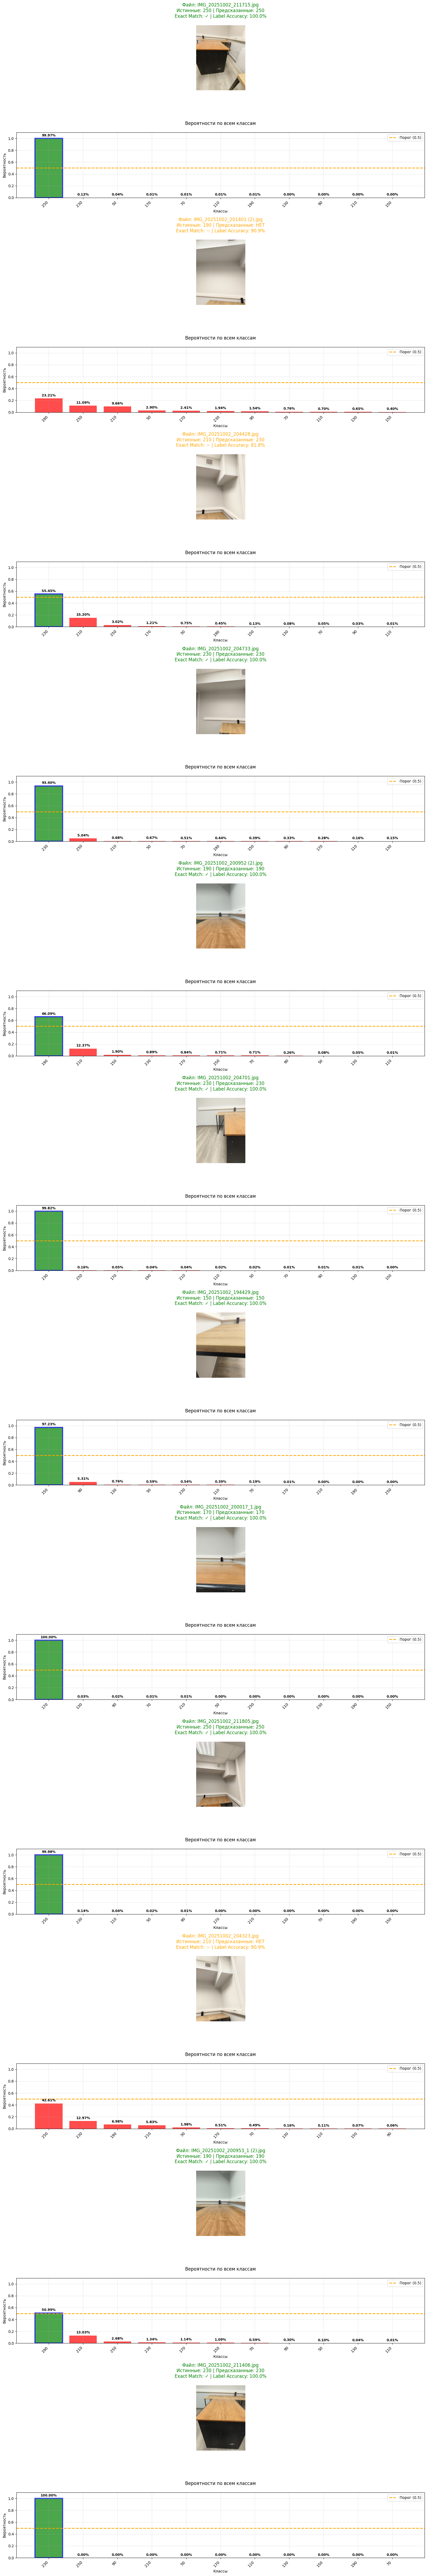

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO
def load_trained_model(model_path, num_classes=None, device='cpu', multi_label=True):
    """
    Загружает обученную модель для multi-label классификации
    
    Args:
        model_path: путь к файлу модели
        num_classes: количество классов (если None, будет определено автоматически)
        device: устройство для загрузки модели
        multi_label: флаг multi-label классификации
    
    Returns:
        model: загруженная модель
        class_names: список названий классов
    """
    try:
        checkpoint = torch.load(model_path, map_location=device)
        
        if 'class_names' in checkpoint:
            class_names = checkpoint['class_names']
            num_classes = len(class_names)
        else:
            print("class_names не найдены в чекпоинте")
            class_names = None
        
        if 'model_architecture' in checkpoint:
            arch = checkpoint['model_architecture']
        else:
            arch = 'resnet18'
        
        is_multi_label = checkpoint.get('multi_label', multi_label)
        print(f"Архитектура модели: {arch}")
        print(f"Количество классов: {num_classes}")
        print(f"Multi-label режим: {is_multi_label}")
        
        if arch == 'resnet18_with_bbox':
            model = ResNetWithBBox(num_classes, pretrained=False)
        elif arch == 'resnet18':
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif arch == 'resnet50':
            model = models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            raise ValueError(f"Неизвестная архитектура: {arch}")
        
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        
        model.to(device)
        model.eval()
        
        print(f"Модель успешно загружена с {device}")
        
        return model, class_names, is_multi_label
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        raise

def predict_with_bbox(model, image_path, class_names, device, transform=None, multi_label=True, threshold=0.5):
    """
    Предсказание для модели с поддержкой bbox параметров
    """
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    print(f"Multi-label режим: {multi_label}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        if hasattr(model, 'bbox_dim'):
            bbox_params = torch.tensor([[0.5, 0.5, 0.1, 0.1]]).to(device)
            model.eval()
            with torch.no_grad():
                outputs = model(image_tensor, bbox_params)
        else:
            model.eval()
            with torch.no_grad():
                outputs = model(image_tensor)
        
        if multi_label:
            probabilities = torch.sigmoid(outputs)
            predicted_probs = probabilities.cpu().numpy()[0]
            
            predicted_labels = (predicted_probs > threshold).astype(int)
            predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
            
            result = {
                'image_path': image_path,
                'predicted_labels': predicted_labels,
                'predicted_classes': predicted_classes,
                'predicted_probs': predicted_probs,
                'class_probabilities': {
                    class_name: prob for class_name, prob in zip(class_names, predicted_probs)
                },
                'threshold': threshold,
                'multi_label': multi_label
            }
            
            print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
            print(f"Порог: {threshold}")
            print("\nВероятности по всем классам:")
            for class_name, prob in zip(class_names, predicted_probs):
                status = "✓" if prob > threshold else "✗"
                print(f"   {class_name}: {prob:.2%} {status}")
                
        else:
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            predicted_prob, predicted_class = torch.max(probabilities, 1)
            predicted_class_name = class_names[predicted_class.item()]
            
            all_probs = probabilities.cpu().numpy()[0]
            
            result = {
                'image_path': image_path,
                'predicted_class': predicted_class_name,
                'confidence': predicted_prob.item(),
                'all_probabilities': all_probs,
                'class_probabilities': {
                    class_name: prob for class_name, prob in zip(class_names, all_probs)
                },
                'multi_label': multi_label
            }
            
            print(f"Предсказанный класс: {predicted_class_name}")
            print(f"Уверенность: {predicted_prob.item():.2%}")
            print("\nВероятности по всем классам:")
            for class_name, prob in zip(class_names, all_probs):
                print(f"   {class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        traceback.print_exc()
        return None

def predict_multiple_images(model, data_folder, class_names, device, num_images=20, 
                          transform=None, multi_label=True, threshold=0.5):
    """
    Предсказывает классы для нескольких изображений (multi-label) с поддержкой bbox
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    all_images = []
    image_true_labels = []
    
    print("Поиск изображений в данных...")
    
    for class_name in class_names:
        class_path = os.path.join(data_folder, class_name)
        if os.path.exists(class_path):
            print(f"Поиск в папке: {class_name}")
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    full_path = os.path.join(class_path, file)
                    
                    true_labels = [0] * len(class_names)
                    class_idx = class_names.index(class_name)
                    true_labels[class_idx] = 1
                    
                    if full_path in all_images:
                        idx = all_images.index(full_path)
                        image_true_labels[idx][class_idx] = 1
                    else:
                        all_images.append(full_path)
                        image_true_labels.append(true_labels)
    
    print(f"Найдено всего изображений: {len(all_images)}")
    
    if len(all_images) == 0:
        print("Не найдено изображений!")
        return []
    
    if len(all_images) < num_images:
        selected_indices = range(len(all_images))
        print(f"Найдено только {len(all_images)} изображений, будем использовать все")
    else:
        selected_indices = random.sample(range(len(all_images)), num_images)
    
    results = []
    
    print(f"\nНачинаем предсказание для {len(selected_indices)} изображений...")
    print("=" * 80)
    
    for i, idx in enumerate(selected_indices):
        image_path = all_images[idx]
        true_labels = image_true_labels[idx]
        
        print(f"\nИзображение {i+1}/{len(selected_indices)}")
        print(f"Файл: {os.path.basename(image_path)}")
        
        true_classes = [class_names[j] for j, label in enumerate(true_labels) if label == 1]
        print(f"Истинные классes: {', '.join(true_classes)}")
        
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            if hasattr(model, 'bbox_dim'):
                bbox_params = torch.tensor([[0.5, 0.5, 0.1, 0.1]]).to(device)
                model.eval()
                with torch.no_grad():
                    outputs = model(image_tensor, bbox_params)
            else:
                model.eval()
                with torch.no_grad():
                    outputs = model(image_tensor)
            
            if multi_label:
                probabilities = torch.sigmoid(outputs)
                predicted_probs = probabilities.cpu().numpy()[0]
                predicted_labels = (predicted_probs > threshold).astype(int)
                predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
                
                if predicted_classes:
                    confidence = np.mean([predicted_probs[j] for j, pred in enumerate(predicted_labels) if pred == 1])
                else:
                    confidence = 0.0
                    
            else:
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
                predicted_classes = [class_names[predicted_class.item()]]
                confidence = predicted_prob.item()
                predicted_labels = [0] * len(class_names)
                predicted_labels[predicted_class.item()] = 1
            
            if multi_label:
                is_exact_match = all(pred == true for pred, true in zip(predicted_labels, true_labels))
                correct_labels = sum(pred == true for pred, true in zip(predicted_labels, true_labels))
                label_accuracy = correct_labels / len(class_names)
                
                result = {
                    'image_path': image_path,
                    'true_labels': true_labels,
                    'true_classes': true_classes,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'predicted_probs': predicted_probs,
                    'confidence': confidence,
                    'is_exact_match': is_exact_match,
                    'label_accuracy': label_accuracy,
                    'multi_label': multi_label
                }
            else:
                is_correct = (predicted_classes[0] in true_classes)
                result = {
                    'image_path': image_path,
                    'true_labels': true_labels,
                    'true_classes': true_classes,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'confidence': confidence,
                    'is_correct': is_correct,
                    'multi_label': multi_label
                }
            
            results.append(result)
            
            if multi_label:
                status = "✅ ТОЧНОЕ СОВПАДЕНИЕ" if is_exact_match else "⚠ ЧАСТИЧНОЕ СОВПАДЕНИЕ"
                print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
                print(f"Уверенность: {confidence:.2%}")
                print(f"Точность по меткам: {label_accuracy:.1%}")
                print(f"Результат: {status}")
            else:
                status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"
                print(f"Предсказанный класс: {predicted_classes[0]}")
                print(f"Уверенность: {confidence:.2%}")
                print(f"Результат: {status}")
            
        except Exception as e:
            print(f"Ошибка при обработке изображения: {e}")
            continue
    
    return results

def predict_image(model, image_path, class_names, device, transform=None, multi_label=True, threshold=0.5):
    """
    Предсказывает классы для одного изображения (multi-label)
    
    Args:
        model: обученная модель
        image_path: путь к изображению
        class_names: список названий классов
        device: устройство для вычислений
        transform: трансформации для изображений
        multi_label: флаг multi-label классификации
        threshold: порог для бинарной классификации
    
    Returns:
        dict: словарь с результатами предсказания
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    print(f"Multi-label режим: {multi_label}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            
            if multi_label:
                probabilities = torch.sigmoid(outputs)
                predicted_probs = probabilities.cpu().numpy()[0]
                
                predicted_labels = (predicted_probs > threshold).astype(int)
                predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
                
                result = {
                    'image_path': image_path,
                    'predicted_labels': predicted_labels,
                    'predicted_classes': predicted_classes,
                    'predicted_probs': predicted_probs,
                    'class_probabilities': {
                        class_name: prob for class_name, prob in zip(class_names, predicted_probs)
                    },
                    'threshold': threshold,
                    'multi_label': multi_label
                }
                
                print(f"Предсказанные классы: {', '.join(predicted_classes) if predicted_classes else 'НЕТ'}")
                print(f"Порог: {threshold}")
                print("\nВероятности по всем классам:")
                for class_name, prob in zip(class_names, predicted_probs):
                    status = "✓" if prob > threshold else "✗"
                    print(f"   {class_name}: {prob:.2%} {status}")
                    
            else:
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
                predicted_class_name = class_names[predicted_class.item()]
                
                all_probs = probabilities.cpu().numpy()[0]
                
                result = {
                    'image_path': image_path,
                    'predicted_class': predicted_class_name,
                    'confidence': predicted_prob.item(),
                    'all_probabilities': all_probs,
                    'class_probabilities': {
                        class_name: prob for class_name, prob in zip(class_names, all_probs)
                    },
                    'multi_label': multi_label
                }
                
                print(f"Предсказанный класс: {predicted_class_name}")
                print(f"Уверенность: {predicted_prob.item():.2%}")
                print("\nВероятности по всем классам:")
                for class_name, prob in zip(class_names, all_probs):
                    print(f"   {class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        traceback.print_exc()
        return None

def predict_image_simple(model, image_path, class_names, device, multi_label=True, threshold=0.5):
    """
    Упрощенная версия функции предсказания для multi-label
    
    Returns:
        list: список предсказанных классов
        list: вероятности для каждого класса
        float: средняя уверенность предсказания
    """
    result = predict_image(model, image_path, class_names, device, multi_label=multi_label, threshold=threshold)
    if result:
        if multi_label:
            return result['predicted_classes'], result['predicted_probs'], np.mean(result['predicted_probs'])
        else:
            return [result['predicted_class']], result['all_probabilities'], result['confidence']
    else:
        return [], [], 0.0

def display_statistics(results, class_names):
    """
    Отображает статистику по результатам multi-label предсказаний
    """
    if not results:
        print("Нет результатов для отображения статистики")
        return
    
    print("\n" + "=" * 80)
    print("СТАТИСТИКА MULTI-LABEL ПРЕДСКАЗАНИЙ")
    print("=" * 80)
    
    total = len(results)
    
    if results[0].get('multi_label', False):
        exact_matches = sum(1 for r in results if r.get('is_exact_match', False))
        exact_accuracy = exact_matches / total * 100
        
        avg_label_accuracy = np.mean([r.get('label_accuracy', 0) for r in results]) * 100
        
        print(f"Общее количество изображений: {total}")
        print(f"Exact Match Accuracy: {exact_accuracy:.2f}% ({exact_matches}/{total})")
        print(f"Average Label Accuracy: {avg_label_accuracy:.2f}%")
        
        print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО КЛАССАМ:")
        for i, class_name in enumerate(class_names):
            true_positives = sum(1 for r in results if r['true_labels'][i] == 1 and r['predicted_labels'][i] == 1)
            false_positives = sum(1 for r in results if r['true_labels'][i] == 0 and r['predicted_labels'][i] == 1)
            false_negatives = sum(1 for r in results if r['true_labels'][i] == 1 and r['predicted_labels'][i] == 0)
            true_negatives = sum(1 for r in results if r['true_labels'][i] == 0 and r['predicted_labels'][i] == 0)
            
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"  {class_name}:")
            print(f"    Precision: {precision:.1%}, Recall: {recall:.1%}, F1: {f1:.1%}")
            print(f"    TP: {true_positives}, FP: {false_positives}, FN: {false_negatives}")
            
    else:
        correct = sum(1 for r in results if r.get('is_correct', False))
        accuracy = correct / total * 100
        
        print(f"Общее количество изображений: {total}")
        print(f"Правильные предсказания: {correct}")
        print(f"Неправильные предсказания: {total - correct}")
        print(f"Точность: {accuracy:.2f}%")

def plot_predictions_grid(results, class_names, max_display=12):
    """
    Визуализирует multi-label предсказания с изображениями и вероятностями для всех классов
    """
    if not results:
        print("Нет результатов для визуализации")
        return
    
    display_results = results[:max_display]
    
    rows = len(display_results) * 2
    cols = 1
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    
    if len(display_results) == 1:
        axes = [axes]
    
    for i, result in enumerate(display_results):
        img_idx = i * 2
        prob_idx = i * 2 + 1
        
        try:
            image = Image.open(result['image_path']).convert('RGB')
            axes[img_idx].imshow(image)
            
            if result.get('multi_label', False):
                true_classes = result['true_classes']
                pred_classes = result['predicted_classes']
                
                exact_match = result.get('is_exact_match', False)
                title_color = 'green' if exact_match else 'orange'
                status = "✓" if exact_match else "~"
                
                axes[img_idx].set_title(
                    f"Файл: {os.path.basename(result['image_path'])}\n"
                    f"Истинные: {', '.join(true_classes)} | "
                    f"Предсказанные: {', '.join(pred_classes) if pred_classes else 'НЕТ'}\n"
                    f"Exact Match: {status} | Label Accuracy: {result.get('label_accuracy', 0):.1%}",
                    color=title_color,
                    fontsize=12,
                    pad=20
                )
            else:
                true_class = result['true_classes'][0] if result['true_classes'] else 'Unknown'
                pred_class = result['predicted_classes'][0] if result['predicted_classes'] else 'Unknown'
                
                is_correct = result.get('is_correct', False)
                title_color = 'green' if is_correct else 'red'
                status = "✓" if is_correct else "✗"
                
                axes[img_idx].set_title(
                    f"Файл: {os.path.basename(result['image_path'])}\n"
                    f"Истинный: {true_class} | Предсказанный: {pred_class}\n"
                    f"Уверенность: {result['confidence']:.1%} {status}",
                    color=title_color,
                    fontsize=12,
                    pad=20
                )
            
            axes[img_idx].axis('off')
            
            if result.get('multi_label', False):
                probs = result['predicted_probs']
                threshold = result.get('threshold', 0.5)
            else:
                probs = result['all_probabilities']
                threshold = 0.5
            
            sorted_indices = np.argsort(probs)[::-1]
            sorted_probs = probs[sorted_indices]
            sorted_classes = [class_names[idx] for idx in sorted_indices]
            
            bars = axes[prob_idx].bar(range(len(sorted_probs)), sorted_probs, 
                                    color=['green' if p > threshold else 'red' for p in sorted_probs],
                                    alpha=0.7)
            
            axes[prob_idx].axhline(y=threshold, color='orange', linestyle='--', 
                                 linewidth=2, label=f'Порог ({threshold})')
            
            axes[prob_idx].set_xlabel('Классы')
            axes[prob_idx].set_ylabel('Вероятность')
            axes[prob_idx].set_title('Вероятности по всем классам', fontsize=12, pad=20)
            axes[prob_idx].set_xticks(range(len(sorted_probs)))
            axes[prob_idx].set_xticklabels(sorted_classes, rotation=45, ha='right')
            axes[prob_idx].set_ylim(0, 1.1)
            axes[prob_idx].grid(True, alpha=0.3)
            axes[prob_idx].legend()
            
            for bar, prob in zip(bars, sorted_probs):
                height = bar.get_height()
                axes[prob_idx].text(bar.get_x() + bar.get_width()/2, height + 0.02,
                                  f'{prob:.2%}', ha='center', va='bottom', 
                                  fontsize=9, fontweight='bold')
            
            predicted_indices = []
            if result.get('multi_label', False):
                predicted_indices = [idx for idx, pred in enumerate(result['predicted_labels']) if pred == 1]
            else:
                if 'predicted_class' in result:
                    predicted_class = result['predicted_class']
                    predicted_indices = [class_names.index(predicted_class)] if predicted_class in class_names else []
            
            for idx in predicted_indices:
                if idx in sorted_indices:
                    pos = np.where(sorted_indices == idx)[0][0]
                    bars[pos].set_edgecolor('blue')
                    bars[pos].set_linewidth(3)
            
        except Exception as e:
            print(f"Ошибка при обработке изображения {result['image_path']}: {e}")
            axes[img_idx].set_title(f"Ошибка загрузки\n{os.path.basename(result['image_path'])}")
            axes[img_idx].axis('off')
            axes[prob_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model, class_names, is_multi_label = load_trained_model(
            'best_resnet18_with_bbox_multilabel.pth', 
            device=device,
            multi_label=True
        )
        print("Multi-label модель с BBox загружена для тестирования")
        print(f"Классы модели: {class_names}")
        
        phone_data_path = "phone_data"
        
        if not os.path.exists(phone_data_path):
            alternative_paths = [
                "Convolutional-Neural-Network/phone_data",
                "./Convolutional-Neural-Network/phone_data", 
                "phone_data/MY_data/test",
                "./phone_data",
                r"C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Convolutional-Neural-Network\Data\phone_data"
            ]
            
            for path in alternative_paths:
                if os.path.exists(path):
                    phone_data_path = path
                    print(f"Найден путь: {phone_data_path}")
                    break
            else:
                print("Не удалось найти папку phone_data!")
                exit()
        
        print(f"\nЗАПУСК MULTI-LABEL ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ")
        print("=" * 80)
        
        results = predict_multiple_images(
            model=model,
            data_folder=phone_data_path,
            class_names=class_names,
            device=device,
            num_images=20,
            multi_label=is_multi_label,
            threshold=0.5
        )
        
        display_statistics(results, class_names)
        
        if results:
            print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
            plot_predictions_grid(results, class_names)
        
    except Exception as e:
        print(f"Ошибка при тестировании: {e}")

# Пример использования для multi-label:
# predicted_classes, probabilities, avg_confidence = predict_image_simple(
#     model, image_path, class_names, device, multi_label=True, threshold=0.5
# )
# print(f"Классы: {predicted_classes}, Средняя уверенность: {avg_confidence:.1%}")

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

In [ ]:
def predict_label_for_image(image_path, model_path='best_resnet18_with_bbox_multilabel.pth', 
                           threshold=0.5, device=None, class_names=None, multi_label=True):
    """
    Функция для предсказания меток для одного изображения.
    
    Args:
        image_path: путь к изображению
        model_path: путь к обученной модели (по умолчанию 'best_resnet18_with_bbox_multilabel.pth')
        threshold: порог для multi-label классификации (по умолчанию 0.5)
        device: устройство для вычислений (cpu/cuda), если None - определится автоматически
        class_names: список названий классов, если None - загрузится из модели
        multi_label: флаг multi-label классификации (по умолчанию True)
    
    Returns:
        dict: словарь с результатами предсказания:
            - 'predicted_classes': список предсказанных классов
            - 'predicted_probs': numpy array вероятностей для всех классов
            - 'confidence': средняя уверенность предсказания
            - 'multi_label': флаг multi-label режима
            - 'class_probabilities': словарь {класс: вероятность}
            - 'image_path': путь к изображению
    """
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        print(f"Анализ изображения: {image_path}")
        
        print("Загрузка модели...")
        model, loaded_class_names, is_multi_label = load_trained_model(
            model_path, 
            device=device,
            multi_label=multi_label
        )
        
        if class_names is None:
            class_names = loaded_class_names
        
        if class_names is None:
            print("Не удалось определить названия классов")
            return None
        
        print(f"Модель загружена. Классы: {len(class_names)}")
        
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            if hasattr(model, 'bbox_dim'):
                bbox_params = torch.tensor([[0.5, 0.5, 0.1, 0.1]]).to(device)
                outputs = model(image_tensor, bbox_params)
            else:
                outputs = model(image_tensor)
            
            if is_multi_label:
                probabilities = torch.sigmoid(outputs)
                predicted_probs = probabilities.cpu().numpy()[0]
                
                predicted_labels = (predicted_probs > threshold).astype(int)
                predicted_classes = [class_names[j] for j, pred in enumerate(predicted_labels) if pred == 1]
                
                if predicted_classes:
                    confidence = np.mean([predicted_probs[j] for j, pred in enumerate(predicted_labels) if pred == 1])
                else:
                    confidence = 0.0
                    
            else:
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
                predicted_classes = [class_names[predicted_class.item()]]
                confidence = predicted_prob.item()
                predicted_probs = probabilities.cpu().numpy()[0]
        
        result = {
            'predicted_classes': predicted_classes,
            'predicted_probs': predicted_probs,
            'confidence': confidence,
            'multi_label': is_multi_label,
            'class_probabilities': {class_name: float(prob) for class_name, prob in zip(class_names, predicted_probs)},
            'image_path': image_path,
            'threshold': threshold if is_multi_label else None
        }
        
        print("\n" + "=" * 50)
        print("РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
        print("=" * 50)
        print(f"Изображение: {os.path.basename(image_path)}")
        print(f"Режим: {'Multi-label' if is_multi_label else 'Single-label'}")
        
        if is_multi_label:
            if predicted_classes:
                print(f"Предсказанные классы: {', '.join(predicted_classes)}")
                print(f"Средняя уверенность: {confidence:.1%}")
            else:
                print("Не определен ни один класс")
            print(f"Порог: {threshold}")
        else:
            if predicted_classes:
                print(f"Предсказанный класс: {predicted_classes[0]}")
                print(f"Уверенность: {confidence:.1%}")
        
        print("\nВероятности по всем классам:")
        for class_name, prob in zip(class_names, predicted_probs):
            if is_multi_label:
                status = "✓" if prob > threshold else "✗"
                print(f"   {class_name}: {prob:.2%} {status}")
            else:
                print(f"   {class_name}: {prob:.2%}")
        
        print("=" * 50)
        
        return result
        
    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        import traceback
        traceback.print_exc()
        return None


def predict_multiple_images_batch(image_paths, model_path='best_resnet18_with_bbox_multilabel.pth', 
                                 threshold=0.5, batch_size=1):
    """
    Предсказывает метки для нескольких изображений.
    
    Args:
        image_paths: список путей к изображениям
        model_path: путь к модели
        threshold: порог классификации
        batch_size: размер батча (не реализовано в этой версии)
    
    Returns:
        list: список результатов для каждого изображения
    """
    results = []
    
    for i, image_path in enumerate(image_paths):
        print(f"\nОбработка изображения {i+1}/{len(image_paths)}: {image_path}")
        result = predict_label_for_image(image_path, model_path, threshold)
        results.append(result)
    
    if results:
        print("\n" + "=" * 60)
        print("СТАТИСТИКА ПО ВСЕМ ИЗОБРАЖЕНИЯМ")
        print("=" * 60)
        
        total_images = len(results)
        valid_results = [r for r in results if r is not None]
        
        print(f"Всего изображений: {total_images}")
        print(f"Успешно обработано: {len(valid_results)}")
        
        if valid_results:
            if valid_results[0]['multi_label']:
                total_predicted = sum(len(r['predicted_classes']) for r in valid_results)
                avg_labels_per_image = total_predicted / len(valid_results)
                print(f"Среднее количество меток на изображение: {avg_labels_per_image:.2f}")
            
            all_classes = {}
            for result in valid_results:
                for cls in result['predicted_classes']:
                    all_classes[cls] = all_classes.get(cls, 0) + 1
            
            if all_classes:
                print("\nРАСПРЕДЕЛЕНИЕ КЛАССОВ:")
                for cls, count in sorted(all_classes.items(), key=lambda x: x[1], reverse=True):
                    print(f"  {cls}: {count} раз ({count/len(valid_results):.1%})")
    
    return results


if __name__ == "__main__":
    test_image = r"C:\Users\user\Desktop\MIPT_year_2\engineer_workshop\Working_directory\Convolutional-Neural-Network\Data\phone_data\130\IMG_20251002_192629.jpg"
    
    if os.path.exists(test_image):
        result = predict_label_for_image(test_image)
    else:
        print(f"Тестовое изображение не найдено: {test_image}")
        print("Используйте существующий путь к изображению для тестирования.")

NameError: name 'os' is not defined